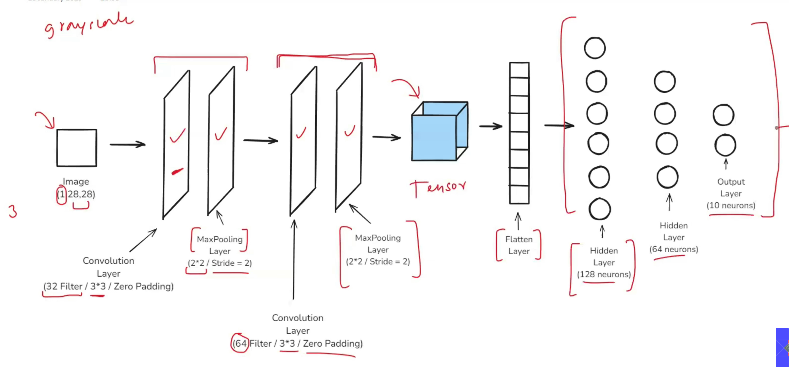

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the specific CSV file
file_path = "fashion-mnist_train.csv"

# Load the dataset directly into a Pandas DataFrame
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "zalando-research/fashionmnist",
  file_path
)

print("First 5 records:", df.head())


/home/kartik-agarwal/Documents/DialogGPT/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0  

In [4]:
torch.device('cuda')

device(type='cuda')

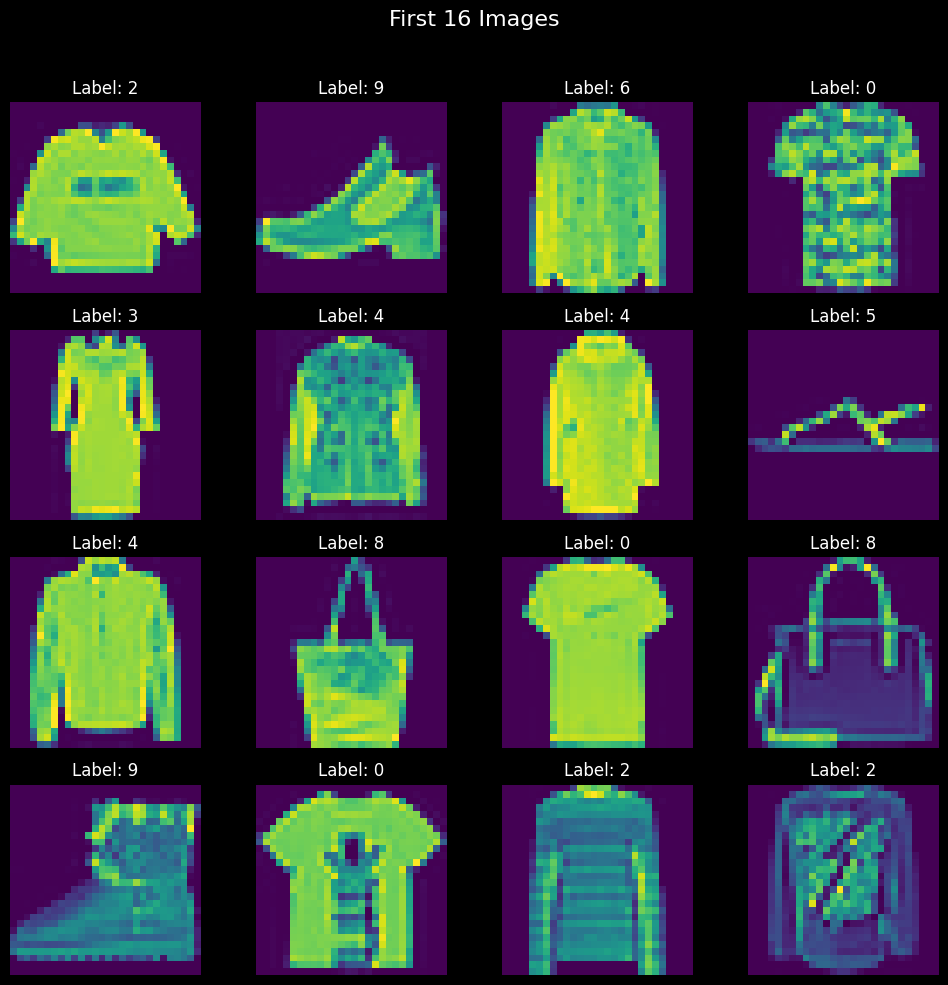

In [5]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [6]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [26]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [27]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [28]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [37]:
# define NN class

class MyNN(nn.Module):

  def __init__(self, input_features):

    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=input_features, out_channels=32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=64*7*7, out_features=128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(in_features=128, out_features=64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(in_features=64, out_features=10),
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [38]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.01

In [39]:
model = MyNN(1)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [40]:
# training loop

for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # calculate loss
    loss = criterion(outputs, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')


Epoch: 1 , Loss: 0.7204386863013108
Epoch: 2 , Loss: 0.42965364566942055
Epoch: 3 , Loss: 0.36362217530608176
Epoch: 4 , Loss: 0.32381800103684266
Epoch: 5 , Loss: 0.29932455865790447
Epoch: 6 , Loss: 0.28169211420665186
Epoch: 7 , Loss: 0.2604782754381498
Epoch: 8 , Loss: 0.24549171532690525
Epoch: 9 , Loss: 0.2306753610149026
Epoch: 10 , Loss: 0.22100918584813675
Epoch: 11 , Loss: 0.2125842672449847
Epoch: 12 , Loss: 0.19969235111027955
Epoch: 13 , Loss: 0.19402554530029495
Epoch: 14 , Loss: 0.18828043783394
Epoch: 15 , Loss: 0.18031269536788264
Epoch: 16 , Loss: 0.17361005538267393
Epoch: 17 , Loss: 0.16017316664382816
Epoch: 18 , Loss: 0.15346388999558985
Epoch: 19 , Loss: 0.14829721518605948
Epoch: 20 , Loss: 0.14466497742539894
Epoch: 21 , Loss: 0.13643739836538832
Epoch: 22 , Loss: 0.13516577363821367
Epoch: 23 , Loss: 0.12905949028084676
Epoch: 24 , Loss: 0.12692047813472648
Epoch: 25 , Loss: 0.12075540854781866
Epoch: 26 , Loss: 0.11848443620993446
Epoch: 27 , Loss: 0.11366585

In [41]:
model.eval()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU

In [42]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9256666666666666


In [43]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9999375
